In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.preprocessing import image as kimage
from tensorflow.keras.preprocessing import image_dataset_from_directory

# **1. Load data and preprocess**

In [3]:
BASE_PATH = '/content/gdrive/MyDrive/DOAN_MOBILENETV3/TB_Chest_Radiography_Database/'

TRAIN_DIR = BASE_PATH + 'train/'
TEST_DIR = BASE_PATH + 'test/'
COLOR_MODE = 'rgb'
IMG_WIDTH = 224
IMG_HEIGHT = 224
IMG_CHANNELS = 3
BATCH_SIZE = 128
BUFFER_SIZE = BATCH_SIZE*5

train_set = image_dataset_from_directory(TRAIN_DIR,
                                            labels='inferred',
                                            label_mode='int',
                                            color_mode=COLOR_MODE,
                                            batch_size=BATCH_SIZE,
                                            image_size=(IMG_WIDTH, IMG_HEIGHT),
                                            shuffle=True,
                                            seed=123,
                                            validation_split=0.2,
                                            subset='training')

dev_set = image_dataset_from_directory(TRAIN_DIR,
                                            labels='inferred',
                                            label_mode='int',
                                            color_mode=COLOR_MODE,
                                            batch_size=BATCH_SIZE,
                                            image_size=(IMG_WIDTH, IMG_HEIGHT),
                                            shuffle=True,
                                            seed=123,
                                            validation_split=0.2,
                                            subset='validation')

test_set = image_dataset_from_directory(TEST_DIR,
                                            labels='inferred',
                                            label_mode='int',
                                            color_mode=COLOR_MODE,
                                            batch_size=BATCH_SIZE,
                                            image_size=(IMG_WIDTH, IMG_HEIGHT),
                                            seed=123)

train_dataset = train_set.cache().prefetch(buffer_size=BUFFER_SIZE)
validation_dataset = dev_set.cache().prefetch(buffer_size=BUFFER_SIZE)



Found 5600 files belonging to 2 classes.
Using 4480 files for training.
Found 5600 files belonging to 2 classes.
Using 1120 files for validation.
Found 1400 files belonging to 2 classes.


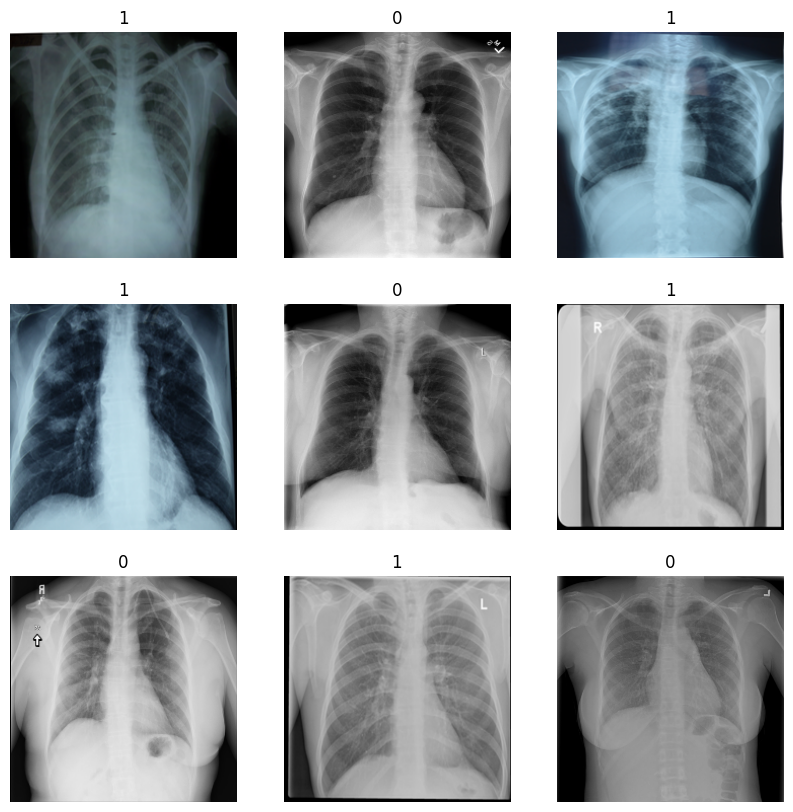

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in dev_set.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.squeeze(images[i].numpy().astype("uint8")))
        plt.title(int(labels[i]))
        plt.axis("off")

# **2. Create model based on Fine-tuning**

In [5]:
from tensorflow.keras import Sequential
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense

# Constants for the model
IMG_WIDTH, IMG_HEIGHT, IMG_CHANNELS = 224, 224, 3

mobilenetv3small = MobileNetV3Small(input_shape=(IMG_WIDTH, IMG_HEIGHT, IMG_CHANNELS),
                                    include_top=False,
                                    weights='imagenet',
                                    classes=2)

# Update BatchNormalization layer names
for layer in mobilenetv3small.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer._name = layer.name.replace('/', '_')

# Freeze the layers of MobileNetV3
for layer in mobilenetv3small.layers:
    layer.trainable = False

# Build the model
flat = Flatten()(mobilenetv3small.layers[-1].output)
fc1 = Dense(1024, activation='relu')(flat)
output = Dense(1, activation='sigmoid')(fc1)

model = Model(inputs=mobilenetv3small.inputs, outputs=output)
model.summary()

# Save the model
model.save('/content/gdrive/MyDrive/DOAN_MOBILENETV3/model_fixed.h5')


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 56, 56,    │        256 │ expanded_conv_sq

 Total params: 29,842,545 (113.84 MB)

 Trainable params: 28,903,425 (110.26 MB)

 Non-trainable params: 939,120 (3.58 MB)

Epoch 1/32
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7611 - loss: 9.6361 

35/35 ━━━━━━━━━━━━━━━━━━━━ 511s 14s/step - accuracy: 0.7645 - loss: 9.4732 - val_accuracy: 0.9786 - val_loss: 0.1100
Epoch 2/32
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9882 - loss: 0.0622

35/35 ━━━━━━━━━━━━━━━━━━━━ 209s 4s/step - accuracy: 0.9883 - loss: 0.0621 - val_accuracy: 0.9848 - val_loss: 0.0627
Epoch 3/32
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9982 - loss: 0.0088

35/35 ━━━━━━━━━━━━━━━━━━━━ 218s 5s/step - accuracy: 0.9982 - loss: 0.0089 - val_accuracy: 0.9911 - val_loss: 0.0250
Epoch 4/32
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9990 - loss: 0.0027

35/35 ━━━━━━━━━━━━━━━━━━━━ 179s 5s/step - accuracy: 0.9990 - loss: 0.0027 - val_accuracy: 0.9937 - val_loss: 0.0196
Epoch 5/32
35/35 ━━━━━━━━━━━━━━━━━━━━ 170s 4s/step - accuracy: 1.0000 - loss: 2.0694e-04 - val_accuracy: 0.9946 - val_loss: 0.0214
Epoch 6/32
35/35 ━━━━━━━━━━━━━━━━━━━━ 147s 4s/step - accuracy: 1.0000 - loss: 8.3202e-05 - val_accuracy: 0.9946 - val_loss: 0.0200
Epoch 7/32
35/35 ━━━━━━━━━━━━━━━━━━━━ 221s 5s/step - accuracy: 1.0000 - loss: 8.6494e-05 - val_accuracy: 0.9946 - val_loss: 0.0204
Epoch 8/32
35/35 ━━━━━━━━━━━━━━━━━━━━ 198s 5s/step - accuracy: 1.0000 - loss: 6.1742e-05 - val_accuracy: 0.9946 - val_loss: 0.0202
Epoch 9/32
35/35 ━━━━━━━━━━━━━━━━━━━━ 162s 5s/step - accuracy: 1.0000 - loss: 6.2471e-05 - val_accuracy: 0.9946 - val_loss: 0.0201


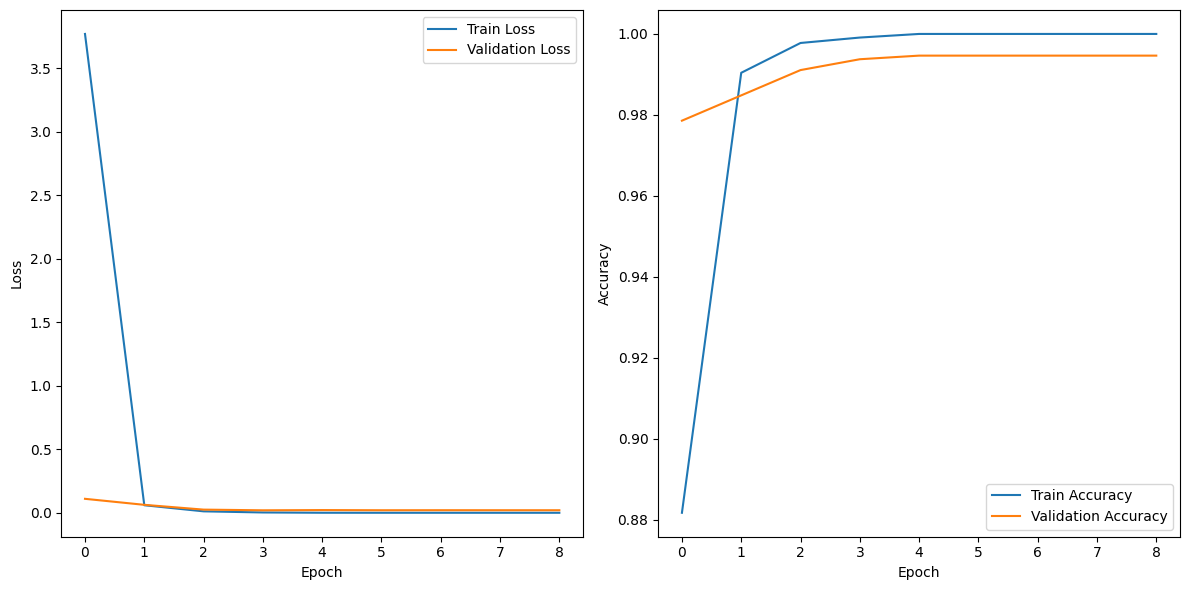

11/11 ━━━━━━━━━━━━━━━━━━━━ 230s 20s/step - accuracy: 0.9764 - loss: 0.1357
Test Loss: 0.1159
Test Accuracy: 0.9757


In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow import keras
import matplotlib.pyplot as plt

# Biên dịch mô hình trước khi huấn luyện
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Tạo callback EarlyStopping để dừng sớm khi không cải thiện
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Tạo callback ModelCheckpoint để lưu mô hình tốt nhất
checkpoint_path = '/content/gdrive/MyDrive/DOAN_MOBILENETV3/best_model3.h5'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)

# Huấn luyện mô hình với các callback
history = model.fit(train_set,
                    epochs=32,
                    validation_data=dev_set,
                    batch_size=1024,
                    callbacks=[early_stopping, checkpoint])

# Vẽ biểu đồ đào tạo
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Đánh giá mô hình trên tập kiểm tra độc lập
test_loss, test_accuracy = model.evaluate(test_set)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')


In [ ]:
history.history

{'loss': [0.016948053613305092,
  0.003014523535966873,
  0.00035905849654227495,
  3.568479951354675e-05,
  1.7496013242634945e-05,
  1.3351180314202793e-05,
  1.132537545345258e-05,
  1.0047769137599971e-05,
  8.894529855751898e-06,
  7.79671154305106e-06],
 'accuracy': [0.9937499761581421,
  0.9991071224212646,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'val_loss': [0.03024982661008835,
  0.021136218681931496,
  0.01673007942736149,
  0.01678878255188465,
  0.016711091622710228,
  0.016868481412529945,
  0.016988271847367287,
  0.01714387722313404,
  0.017374172806739807,
  0.017540398985147476],
 'val_accuracy': [0.9910714030265808,
  0.9946428537368774,
  0.9955357313156128,
  0.9955357313156128,
  0.9955357313156128,
  0.9955357313156128,
  0.9955357313156128,
  0.9955357313156128,
  0.9955357313156128,
  0.9955357313156128]}

In [ ]:
import json
with open('/content/gdrive/MyDrive/DOAN_MOBILENETV3/history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
print(history.history.keys())
print(history.history['val_accuracy'][-1])

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])
0.9955357313156128


In [ ]:
model = keras.models.load_model('/content/gdrive/MyDrive/DOAN_MOBILENETV3/best_model3.h5')


1/1 [==============================] - 0s 81ms/step


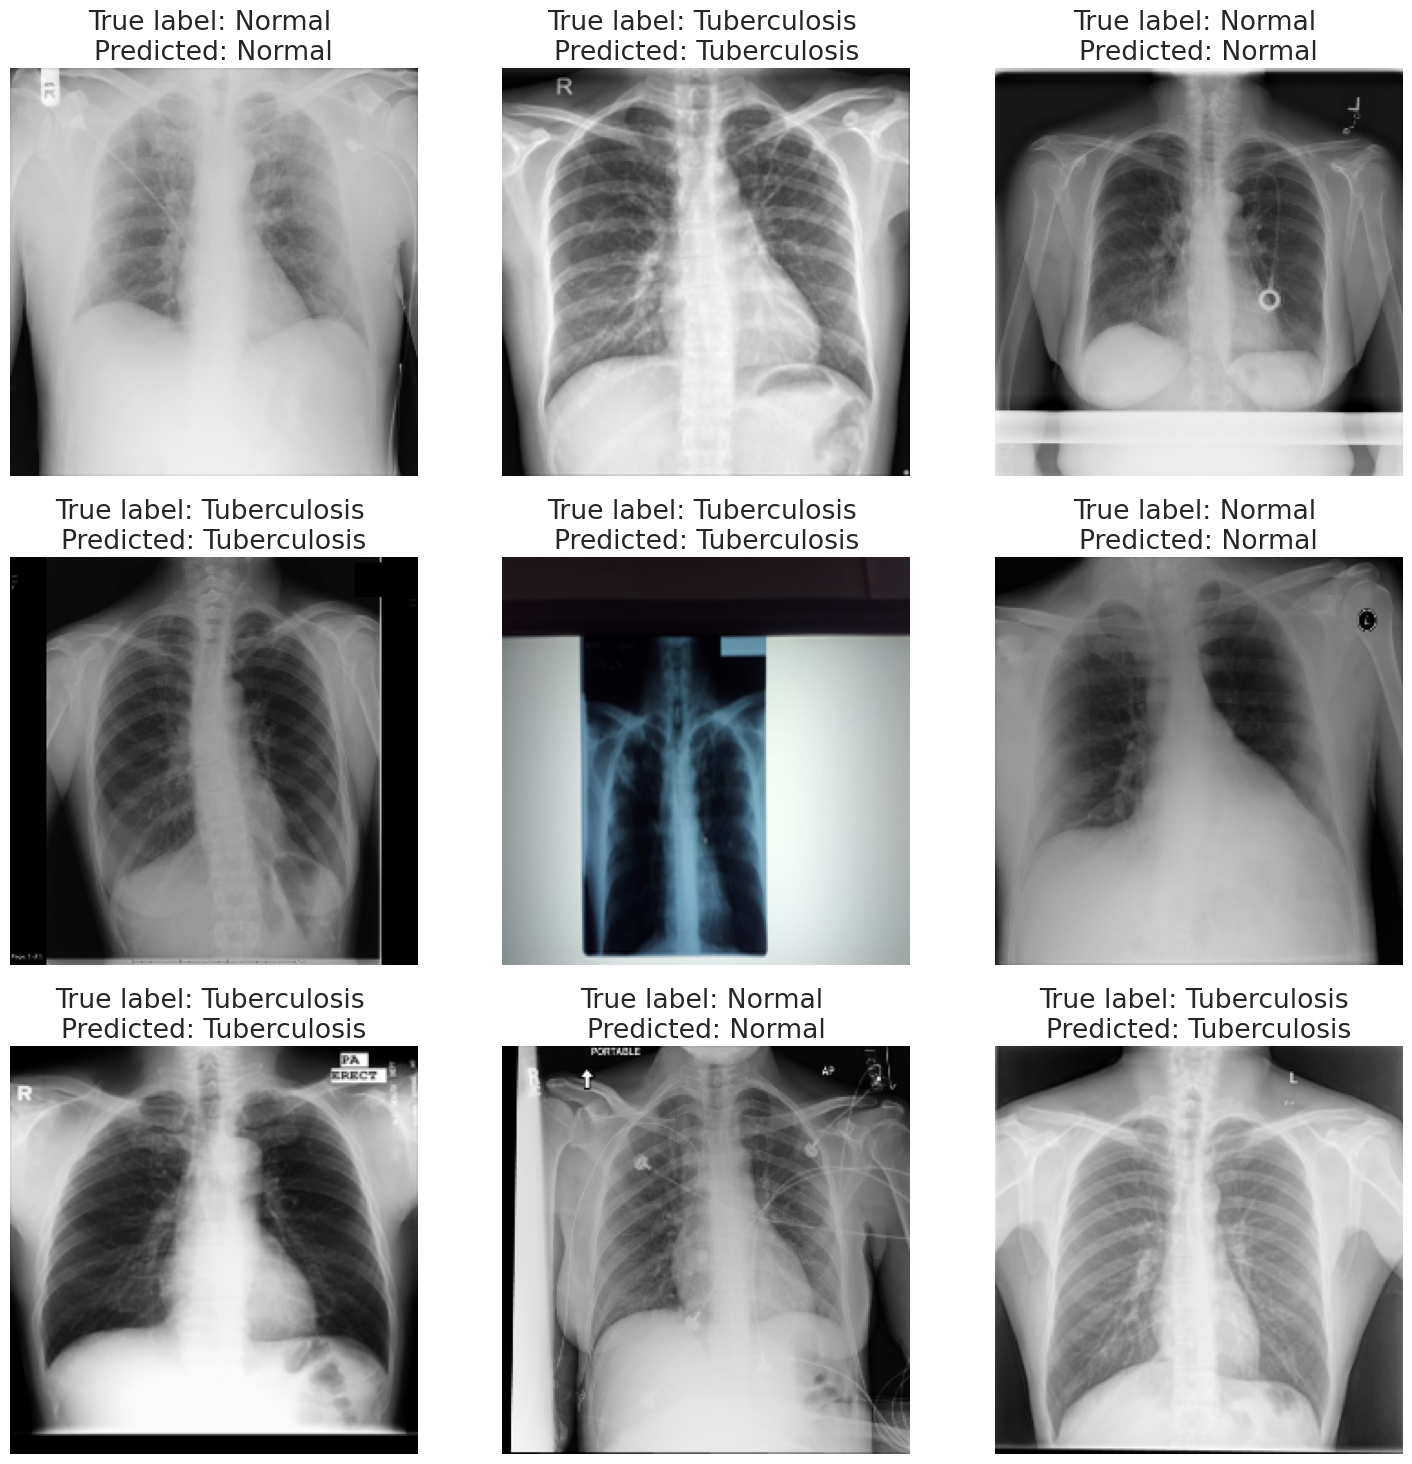

4/4 [==============================] - 2s 538ms/step
Accuracy:  0.9907142857142858
Precision:  1.0
Recall:  0.9814285714285714
F1:  0.9906272530641673


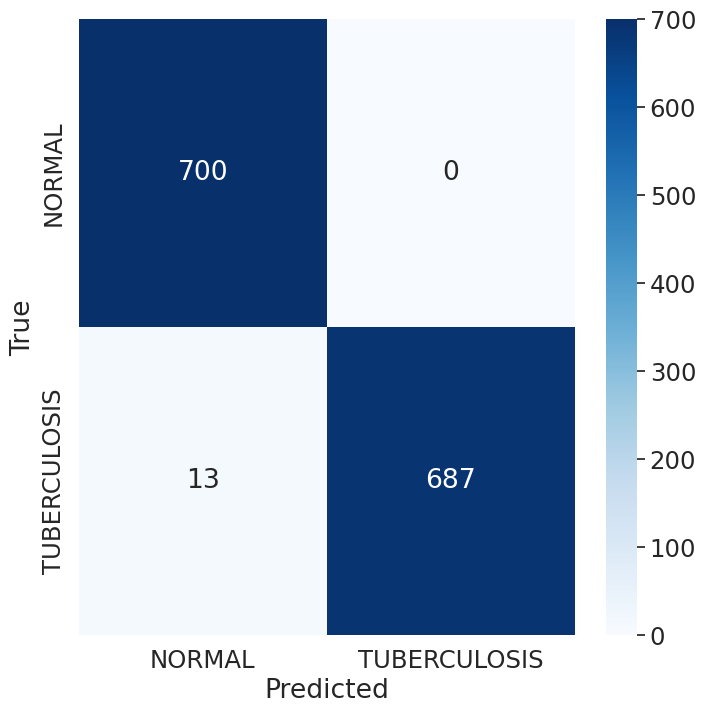

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       700
           1       1.00      0.98      0.99       700

    accuracy                           0.99      1400
   macro avg       0.99      0.99      0.99      1400
weighted avg       0.99      0.99      0.99      1400



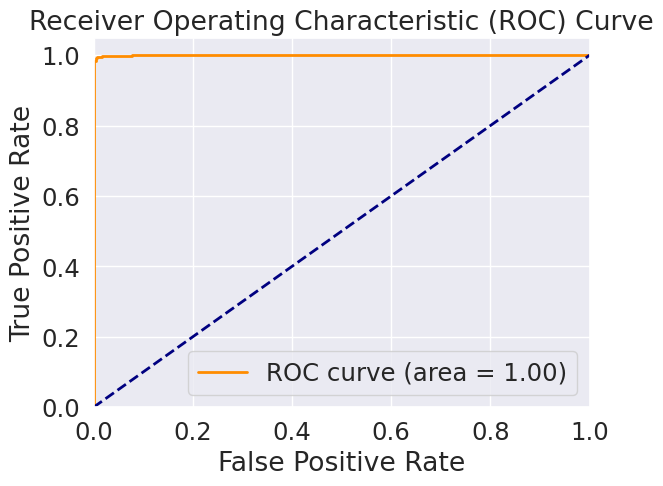

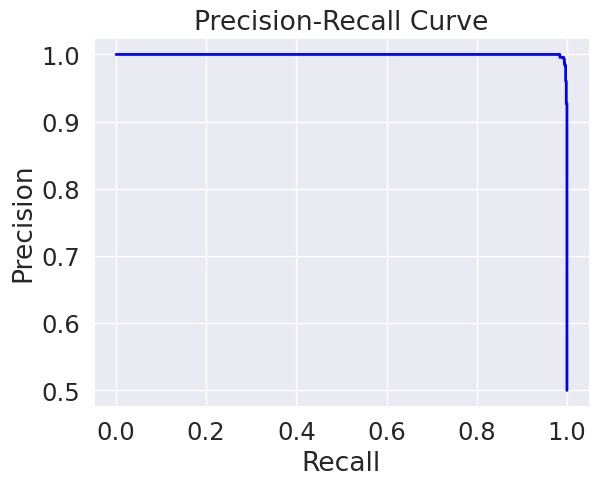

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Mô hình và kết quả đánh giá đã được lưu.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve
import seaborn as sn
import pandas as pd
import numpy as np

def display_images_with_predictions(model, test_set):
    plt.figure(figsize=(18, 18))
    for images, labels in test_set.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(np.squeeze(images[i].numpy().astype("uint8")))
            plt.axis("off")

            # Dự đoán và lưu lại nhãn dự đoán
            pred = model.predict(np.expand_dims(images[i], axis=0))[0]
            if pred > 0.5:
                prediction = "Tuberculosis"
            else:
                prediction = "Normal"

            if int(labels[i]) == 1:
                true_label = "Tuberculosis"
            else:
                true_label = "Normal"

            plt.title(f"True label: {true_label} \nPredicted: {prediction}")

    plt.show()

def evaluate_model(model, test_set):
    y_true = []
    y_pred = []
    y_pred_prob = []

    for images, labels in test_set:
        preds = model.predict(images)
        y_pred_prob.extend(preds)
        preds = [1 if i > 0.5 else 0 for i in preds]
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)

    print("Accuracy: ", acc)
    print("Precision: ", precision)
    print("Recall: ", recall)
    print("F1: ", f1)

    df_cm = pd.DataFrame(conf_matrix, index=['NORMAL', 'TUBERCULOSIS'], columns=['NORMAL', 'TUBERCULOSIS'])
    plt.figure(figsize=(8, 8))
    sn.set(font_scale=1.6)
    sn.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print(classification_report(y_true, y_pred))

    # ROC Curve and AUC
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_pred_prob)
    plt.figure()
    plt.plot(recall, precision, color='blue', lw=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.show()

    return acc, precision, recall, f1

# Hiển thị hình ảnh và dự đoán của mô hình
display_images_with_predictions(model, test_set)

# Đánh giá mô hình
acc, precision, recall, f1 = evaluate_model(model, test_set)

# Lưu lại mô hình đã được huấn luyện
model.save('/content/gdrive/MyDrive/DOAN_MOBILENETV3/final_model3.h5')

# Lưu các kết quả đánh giá vào một file CSV
evaluation_results = {
    'Accuracy': acc,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
}

df_results = pd.DataFrame([evaluation_results])
df_results.to_csv('/content/gdrive/MyDrive/DOAN_MOBILENETV3/evaluation_results3.csv', index=False)

print("Mô hình và kết quả đánh giá đã được lưu.")


1/1 [==============================] - 0s 51ms/step


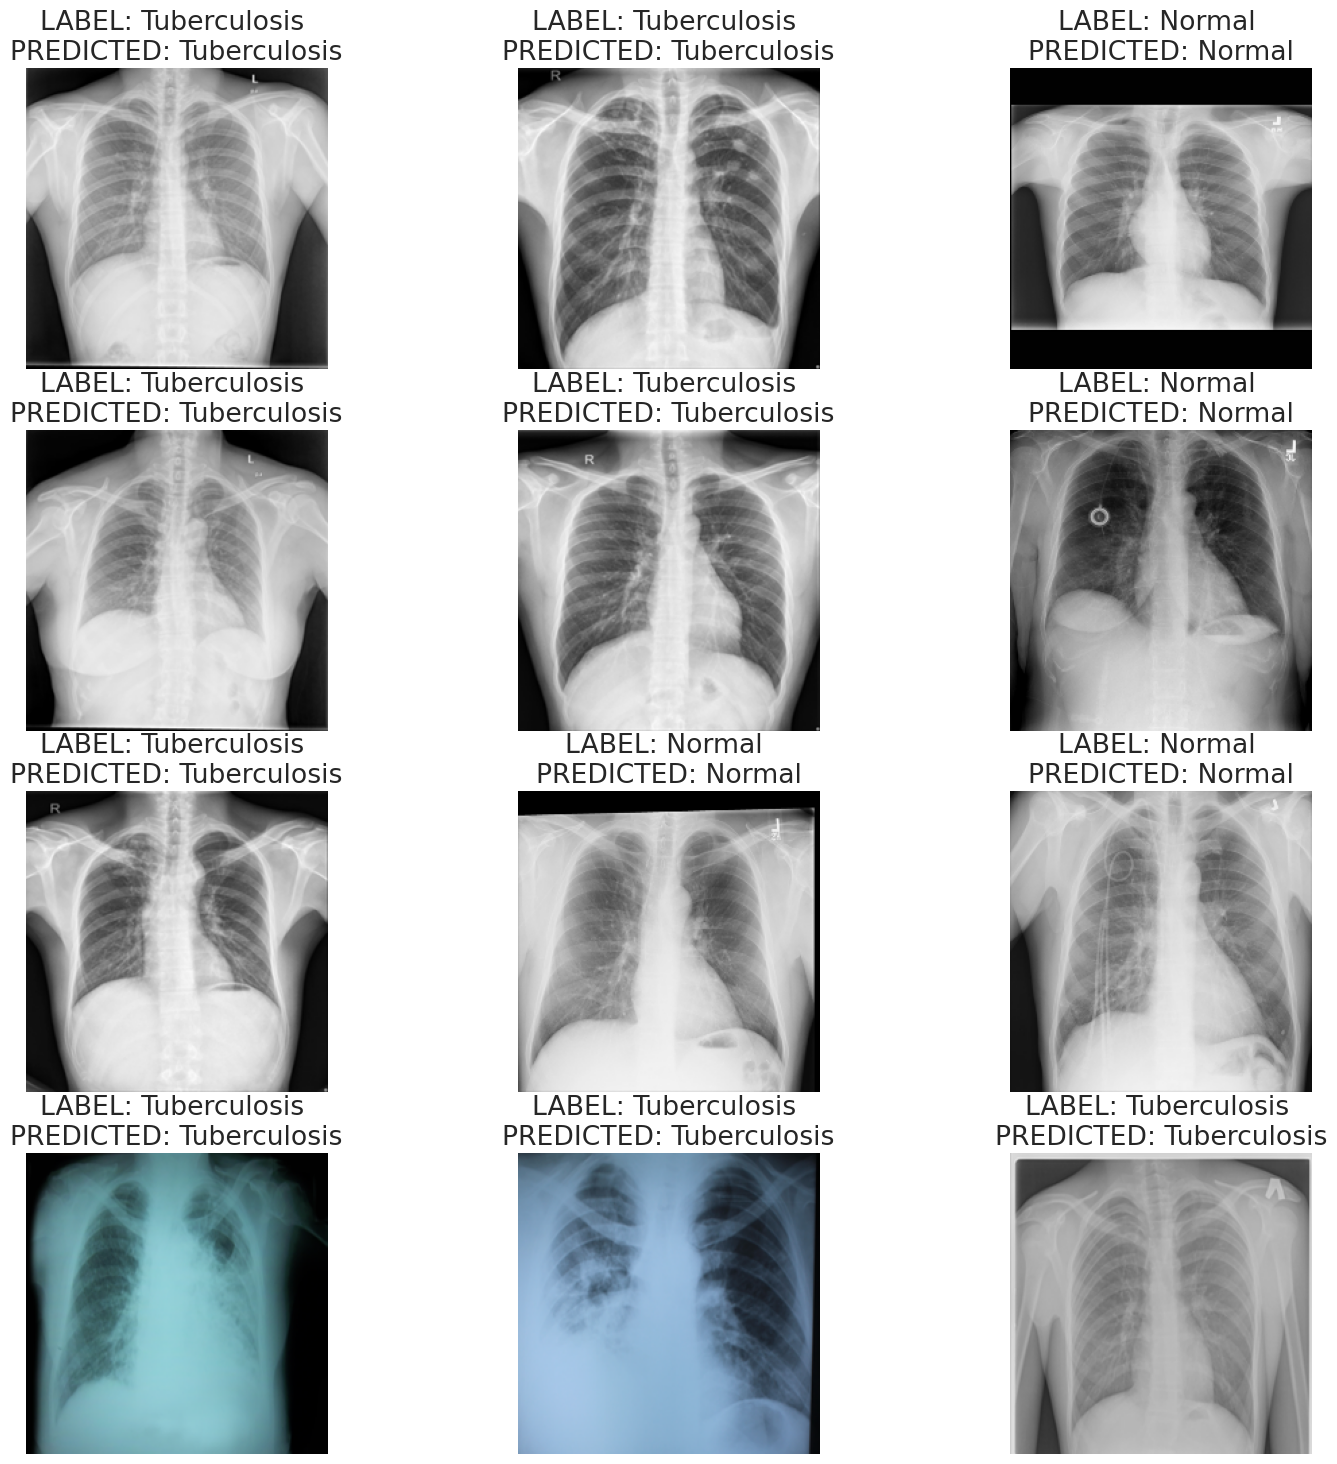

4/4 [==============================] - 2s 508ms/step
Accuracy:  0.9878571428571429
Precision:  1.0
Recall:  0.9757142857142858
F1:  0.987707881417209


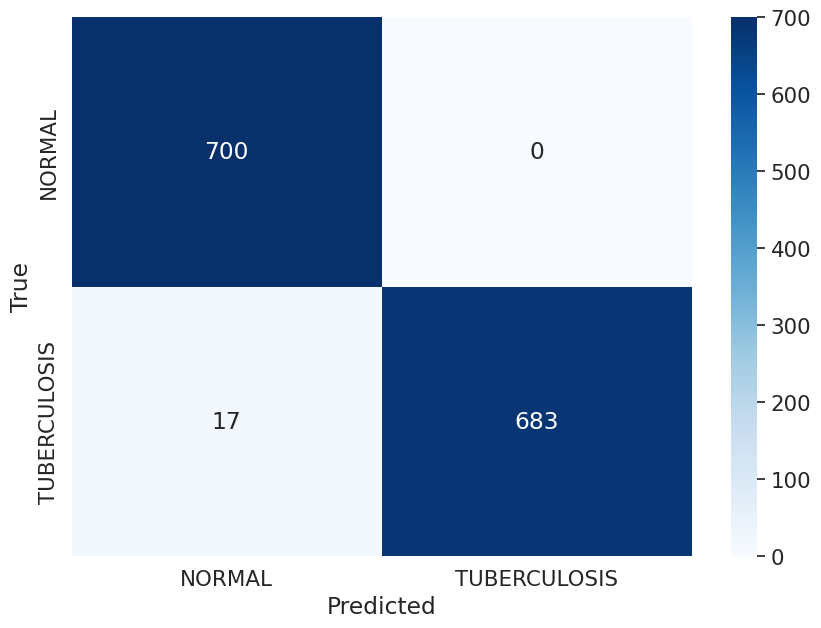

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       700
           1       1.00      0.98      0.99       700

    accuracy                           0.99      1400
   macro avg       0.99      0.99      0.99      1400
weighted avg       0.99      0.99      0.99      1400



/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Mô hình và kết quả đánh giá đã được lưu.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sn

def display_images_with_predictions(model, test_set):
    plt.figure(figsize=(18, 18))
    for images, labels in test_set.take(1):
        for i in range(12):
            ax = plt.subplot(4, 3, i + 1)
            plt.imshow(np.squeeze(images[i].numpy().astype("uint8")))
            plt.axis("off")

            # Dự đoán và lưu lại nhãn dự đoán
            pred = model.predict(np.expand_dims(images[i], axis=0))[0]
            if pred > 0.8:
                prediction = "Tuberculosis"
            else:
                prediction = "Normal"

            if int(labels[i]) == 1:
                true_label = "Tuberculosis"
            else:
                true_label = "Normal"

            plt.title(f"LABEL: {true_label} \nPREDICTED: {prediction}")

    plt.show()

def evaluate_model(model, test_set):
    y_true = []
    y_pred = []

    for images, labels in test_set:
        preds = model.predict(images)
        preds = [1 if i > 0.8 else 0 for i in preds]
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)

    print("Accuracy: ", acc)
    print("Precision: ", precision)
    print("Recall: ", recall)
    print("F1: ", f1)

    df_cm = pd.DataFrame(conf_matrix, index=['NORMAL', 'TUBERCULOSIS'], columns=['NORMAL', 'TUBERCULOSIS'])
    plt.figure(figsize=(10, 7))
    sn.set(font_scale=1.4)
    sn.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print(classification_report(y_true, y_pred))

    return acc, precision, recall, f1

# Hiển thị hình ảnh và dự đoán của mô hình
display_images_with_predictions(model, test_set)

# Đánh giá mô hình
acc, precision, recall, f1 = evaluate_model(model, test_set)

# Lưu lại mô hình đã được huấn luyện
model.save('/content/gdrive/MyDrive/DOAN_MOBILENETV3/final_model4.h5')

# Lưu các kết quả đánh giá vào một file CSV
evaluation_results = {
    'Accuracy': acc,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
}

df_results = pd.DataFrame([evaluation_results])
df_results.to_csv('/content/gdrive/MyDrive/DOAN_MOBILENETV3/evaluation_results2.csv', index=False)

print("Mô hình và kết quả đánh giá đã được lưu.")
